1. Load data and train models

In [8]:
from pathlib import Path

import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED_PATH = PROJECT_ROOT / "data" / "processed"

X_train = pd.read_csv(PROCESSED_PATH / "X_train.csv")
X_test = pd.read_csv(PROCESSED_PATH / "X_test.csv")
y_train = pd.read_csv(PROCESSED_PATH / "y_train.csv").squeeze("columns")
y_test = pd.read_csv(PROCESSED_PATH / "y_test.csv").squeeze("columns")

numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()
categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features)
    ]
)

trained_models = {
    "Logistic Regression": Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", LogisticRegression(max_iter=1000))
        ]
    ),
    "Random Forest": Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", RandomForestClassifier(
                n_estimators=200,
                random_state=42,
                class_weight="balanced"
            ))
        ]
    )
}

for model in trained_models.values():
    model.fit(X_train, y_train)

print("Trained models:", list(trained_models))

C:\Users\lalil\AppData\Local\Temp\ipykernel_9544\1649757262.py:22: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(


Trained models: ['Logistic Regression', 'Random Forest']


1. Evaluation imports

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

2. Evaluate models

In [10]:
results = []

for name, model in trained_models.items():

    predictions = model.predict(X_test)

    probabilities = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(
            y_test,
            predictions
        ),
        "Precision": precision_score(
            y_test,
            predictions
        ),
        "Recall": recall_score(
            y_test,
            predictions
        ),
        "F1": f1_score(
            y_test,
            predictions
        ),
        "ROC_AUC": roc_auc_score(
            y_test,
            probabilities
        )
    })

results_df = pd.DataFrame(results)

results_df.sort_values(
    "ROC_AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.805536,0.657233,0.558824,0.604046,0.841861
1,Random Forest,0.763662,0.548463,0.620321,0.582183,0.822457


3. Confusion matrix

In [11]:
#For your selected model:

best_model_name = results_df.sort_values(
    "ROC_AUC",
    ascending=False
).iloc[0]["Model"]

best_model = trained_models[best_model_name]

y_pred = best_model.predict(X_test)

cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[926 109]
 [165 209]]


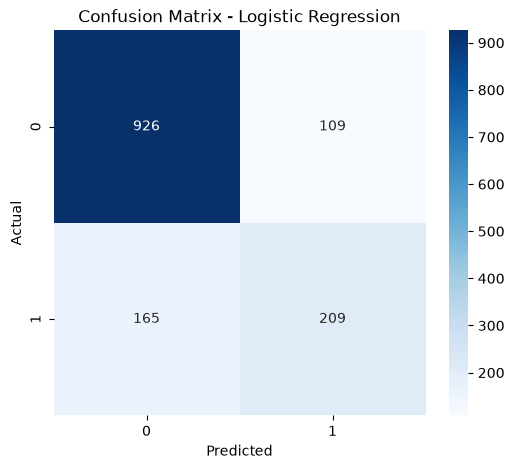

In [12]:
#Visualize:

import seaborn as sns

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - {best_model_name}")

plt.show()

4. ROC curve

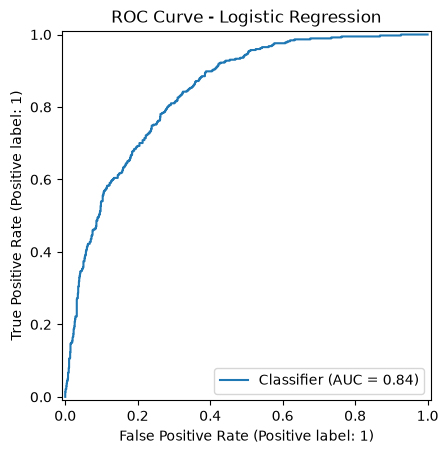

In [13]:
RocCurveDisplay.from_predictions(
    y_test,
    best_model.predict_proba(X_test)[:, 1]
)

plt.title(f"ROC Curve - {best_model_name}")

plt.show()

5. Cross-validation

Why?

A single train/test split can sometimes give a misleading result.

Five-fold cross-validation tests the model across multiple partitions of the training data.

In [14]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    best_model,
    X_train,
    y_train,
    cv=5,
    scoring="roc_auc"
)

print("CV scores:", cv_scores)
print("Mean CV ROC-AUC:", cv_scores.mean())
print("Std:", cv_scores.std())

CV scores: [0.86359524 0.85312556 0.85094033 0.83604366 0.82410332]
Mean CV ROC-AUC: 0.8455616199670255
Std: 0.013873754556610295


In [ ]:
6. Save results

In [15]:
reports_path = PROJECT_ROOT / "reports"

reports_path.mkdir(
    parents=True,
    exist_ok=True
)

results_df.to_csv(
    reports_path / "model_results.csv",
    index=False
)

7. Hyperparameter tuning

In [18]:
# For XGBoost:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        eval_metric="logloss",
        random_state=42
    ))
])

In [ ]:
#Parameter search:

param_grid = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [3, 4, 5, 6],
    "model__learning_rate": [
        0.01,
        0.05,
        0.1
    ],
    "model__subsample": [
        0.7,
        0.8,
        1.0
    ],
    "model__colsample_bytree": [
        0.7,
        0.8,
        1.0
    ]
}

In [20]:
#Search:

search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_grid,
    n_iter=20,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=-1
)

search.fit(
    X_train,
    y_train
)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__colsample_bytree': [0.7, 0.8, ...], 'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [3, 4, ...], 'model__n_estimators': [100, 200, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``R

In [21]:
#check:

print(search.best_params_)
print(search.best_score_)

{'model__subsample': 0.7, 'model__n_estimators': 500, 'model__max_depth': 3, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.7}
0.8498542868898975


I compared several candidate algorithms using the same train/test methodology and evaluation metrics. I then used cross-validation and hyperparameter search to investigate whether the strongest candidate was stable and whether tuning improved its performance

In [ ]:
import pandas as pd

TARGET_COLUMN = "Churn"
ID_COLUMNS = ["customerID"]


def load_data(path):
    df = pd.read_csv(path)

    return df


def clean_data(df):
    df = df.copy()

    if "TotalCharges" in df.columns:
        df["TotalCharges"] = pd.to_numeric(
            df["TotalCharges"],
            errors="coerce"
        )

    columns_to_drop = [
        col for col in ID_COLUMNS
        if col in df.columns
    ]

    if columns_to_drop:
        df = df.drop(
            columns=columns_to_drop
        )

    return df


def prepare_target(df):
    df = df.copy()

    if TARGET_COLUMN in df.columns:
        df[TARGET_COLUMN] = df[TARGET_COLUMN].map({
            "No": 0,
            "Yes": 1
        })

    return df